In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import MinMaxScaler, LabelEncoder

In [2]:
df = pd.read_csv("hotel_booking.csv")
df.head()

,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,...,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date,name,email,phone-number,credit_card
0,Resort Hotel,0,342,2015,July,27,1,0,0,2,...,Transient,0.0,0,0,Check-Out,2015-07-01,Ernest Barnes,Ernest.Barnes31@outlook.com,669-792-1661,************4322
1,Resort Hotel,0,737,2015,July,27,1,0,0,2,...,Transient,0.0,0,0,Check-Out,2015-07-01,Andrea Baker,Andrea_Baker94@aol.com,858-637-6955,************9157
2,Resort Hotel,0,7,2015,July,27,1,0,1,1,...,Transient,75.0,0,0,Check-Out,2015-07-02,Rebecca Parker,Rebecca_Parker@comcast.net,652-885-2745,************3734
3,Resort Hotel,0,13,2015,July,27,1,0,1,1,...,Transient,75.0,0,0,Check-Out,2015-07-02,Laura Murray,Laura_M@gmail.com,364-656-8427,************5677
4,Resort Hotel,0,14,2015,July,27,1,0,2,2,...,Transient,98.0,0,1,Check-Out,2015-07-03,Linda Hines,LHines@verizon.com,713-226-5883,************5498


In [3]:
print(df.shape)
df.info()

(119390, 36)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 119390 entries, 0 to 119389
Data columns (total 36 columns):
 #   Column                          Non-Null Count   Dtype  
---  ------                          --------------   -----  
 0   hotel                           119390 non-null  object 
 1   is_canceled                     119390 non-null  int64  
 2   lead_time                       119390 non-null  int64  
 3   arrival_date_year               119390 non-null  int64  
 4   arrival_date_month              119390 non-null  object 
 5   arrival_date_week_number        119390 non-null  int64  
 6   arrival_date_day_of_month       119390 non-null  int64  
 7   stays_in_weekend_nights         119390 non-null  int64  
 8   stays_in_week_nights            119390 non-null  int64  
 9   adults                          119390 non-null  int64  
 10  children                        119386 non-null  float64
 11  babies                          119390 non-null  int64  
 12  mea

In [4]:
print("Missing Values\n")
print(df.isnull().sum())

Missing Values

hotel                                  0
is_canceled                            0
lead_time                              0
arrival_date_year                      0
arrival_date_month                     0
arrival_date_week_number               0
arrival_date_day_of_month              0
stays_in_weekend_nights                0
stays_in_week_nights                   0
adults                                 0
children                               4
babies                                 0
meal                                   0
country                              488
market_segment                         0
distribution_channel                   0
is_repeated_guest                      0
previous_cancellations                 0
previous_bookings_not_canceled         0
reserved_room_type                     0
assigned_room_type                     0
booking_changes                        0
deposit_type                           0
agent                              16340


In [5]:
numeric_cols = df.select_dtypes(include=np.number).columns

df[numeric_cols] = df[numeric_cols].fillna(
    df[numeric_cols].median()
)

print(df.isnull().sum())

hotel                               0
is_canceled                         0
lead_time                           0
arrival_date_year                   0
arrival_date_month                  0
arrival_date_week_number            0
arrival_date_day_of_month           0
stays_in_weekend_nights             0
stays_in_week_nights                0
adults                              0
children                            0
babies                              0
meal                                0
country                           488
market_segment                      0
distribution_channel                0
is_repeated_guest                   0
previous_cancellations              0
previous_bookings_not_canceled      0
reserved_room_type                  0
assigned_room_type                  0
booking_changes                     0
deposit_type                        0
agent                               0
company                             0
days_in_waiting_list                0
customer_typ

In [6]:
print("Duplicate Rows :", df.duplicated().sum())

df.drop_duplicates(inplace=True)

print("After Removal :", df.shape)

Duplicate Rows : 0
After Removal : (119390, 36)


In [7]:
Q1 = df["adr"].quantile(0.25)
Q3 = df["adr"].quantile(0.75)

IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

outliers = df[(df["adr"] < lower) |
              (df["adr"] > upper)]

print(outliers.head())

            hotel  is_canceled  lead_time  arrival_date_year  \
140  Resort Hotel            0         44               2015   
303  Resort Hotel            0         79               2015   
396  Resort Hotel            0        317               2015   
412  Resort Hotel            0         37               2015   
523  Resort Hotel            0          0               2015   

    arrival_date_month  arrival_date_week_number  arrival_date_day_of_month  \
140               July                        28                          5   
303               July                        28                         11   
396               July                        29                         14   
412               July                        29                         15   
523               July                        29                         18   

     stays_in_weekend_nights  stays_in_week_nights  adults  ...  \
140                        2                     0       3  ...   
303   

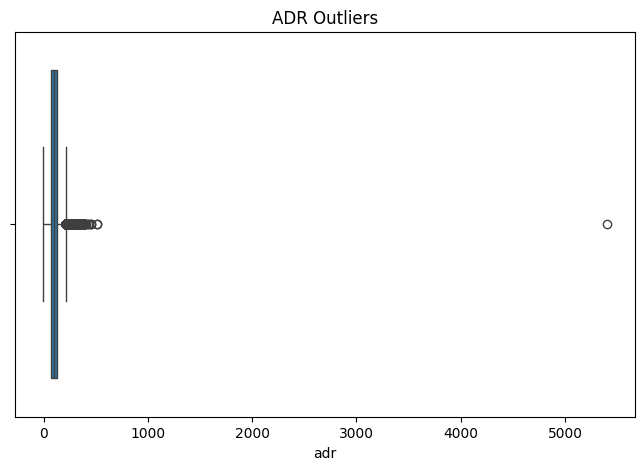

In [8]:
plt.figure(figsize=(8,5))

sns.boxplot(x=df["adr"])

plt.title("ADR Outliers")

plt.show()

In [9]:
scaler = MinMaxScaler()

df[["adr"]] = scaler.fit_transform(df[["adr"]])

print(df[["adr"]].head())

        adr
0  0.001180
1  0.001180
2  0.015053
3  0.015053
4  0.019307


In [10]:
encoder = LabelEncoder()

df["hotel"] = encoder.fit_transform(df["hotel"])

print(df[["hotel"]].head())

   hotel
0      1
1      1
2      1
3      1
4      1


In [11]:
hotel = pd.get_dummies(df["hotel"])

print(hotel.head())

       0     1
0  False  True
1  False  True
2  False  True
3  False  True
4  False  True


In [12]:
df.to_csv("cleaned_hotel_booking.csv", index=False)

print("Cleaned dataset saved successfully.")

Cleaned dataset saved successfully.
